In [1]:
import os
os.chdir(r"D:/Projects/Poverty Predictor Bd")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

os.makedirs("outputs/figures", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("models", exist_ok=True)

df = pd.read_csv("data/processed/master_features.csv")

FEATURE_COLS = [
    'ntl_mean', 'ntl_std', 'ntl_max',
    'ntl_per_capita', 'ntl_trend', 'ntl_yoy_change', 'ntl_iqr',
    'pop_density',
    'ndvi_mean', 'ndvi_std',
    'urban_fraction', 'water_fraction',
    'elevation_mean', 'elevation_std',
    'road_density',
    'ntl_mean_spatial_lag', 'ntl_per_capita_spatial_lag',
    'ndvi_mean_spatial_lag', 'pop_density_spatial_lag',
]
TARGET = 'poverty_hcr'

X = df[FEATURE_COLS]
y = df[TARGET]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y range: {y.min()} — {y.max()}")
print(f"Unique y values: {sorted(y.unique())}")

X shape: (64, 19)
y shape: (64,)
y range: 14.8 — 26.9
Unique y values: [np.float64(14.8), np.float64(15.8), np.float64(16.7), np.float64(17.4), np.float64(17.9), np.float64(24.2), np.float64(24.8), np.float64(26.9)]


In [2]:
# Standard k-fold would leak information because neighboring districts
# have correlated features. Instead we use division-based CV —
# hold out one division at a time (8 folds = 8 divisions)

divisions = df['division_name'].values
unique_divisions = sorted(df['division_name'].unique())

print("Spatial CV folds (leave-one-division-out):")
for div in unique_divisions:
    n = (divisions == div).sum()
    print(f"  {div:<15} {n} districts")

# Scaler — RobustScaler handles outliers better than StandardScaler
scaler = RobustScaler()

Spatial CV folds (leave-one-division-out):
  Barishal        6 districts
  Chattogram      11 districts
  Dhaka           13 districts
  Khulna          10 districts
  Mymensingh      4 districts
  Rajshahi        8 districts
  Rangpur         8 districts
  Sylhet          4 districts


In [3]:
def spatial_cv_evaluate(model, X, y, divisions, scaler):
    """
    Leave-one-division-out cross validation.
    Train on 7 divisions, test on 1, rotate through all 8.
    Returns per-fold and aggregate metrics.
    """
    unique_divs = sorted(set(divisions))
    results = []
    all_preds = np.zeros(len(y))
    
    for div in unique_divs:
        test_mask  = divisions == div
        train_mask = ~test_mask
        
        X_train = X[train_mask]
        X_test  = X[test_mask]
        y_train = y[train_mask]
        y_test  = y[test_mask]
        
        # Scale within fold (fit on train only)
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)
        
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc)
        all_preds[test_mask] = preds
        
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        mae  = mean_absolute_error(y_test, preds)
        r2   = r2_score(y_test, preds) if len(y_test) > 1 else float('nan')
        
        results.append({
            'division': div,
            'n_test':   test_mask.sum(),
            'rmse':     round(rmse, 3),
            'mae':      round(mae, 3),
            'r2':       round(r2, 3),
            'y_true':   y_test.values,
            'y_pred':   preds
        })
    
    # Aggregate metrics
    rmse_all = round(np.sqrt(mean_squared_error(y, all_preds)), 3)
    mae_all  = round(mean_absolute_error(y, all_preds), 3)
    r2_all   = round(r2_score(y, all_preds), 3)
    
    return results, rmse_all, mae_all, r2_all, all_preds


def print_results(name, results, rmse, mae, r2):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  {'Division':<18} {'N':>4} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print(f"  {'-'*50}")
    for r in results:
        print(f"  {r['division']:<18} {r['n_test']:>4} "
              f"{r['rmse']:>8.3f} {r['mae']:>8.3f} {r['r2']:>8.3f}")
    print(f"  {'-'*50}")
    print(f"  {'OVERALL':<18} {'64':>4} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}")

In [4]:
results_log = {}  # store all model results for comparison

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)':        Ridge(alpha=1.0),
    'Lasso (L1)':        Lasso(alpha=0.1),
}

for name, model in models.items():
    results, rmse, mae, r2, preds = spatial_cv_evaluate(
        model, X, y, divisions, RobustScaler()
    )
    print_results(name, results, rmse, mae, r2)
    results_log[name] = {
        'rmse': rmse, 'mae': mae, 'r2': r2, 'preds': preds
    }


  Linear Regression
  Division              N     RMSE      MAE       R²
  --------------------------------------------------
  Barishal              6   10.064    9.988 -8023779872579955416000404389888.000
  Chattogram           11    7.209    5.833 -4117334238904331461098217668608.000
  Dhaka                13   60.858   26.301 -293438132913243233189863169720320.000
  Khulna               10    8.196    7.044 -21286825362026771388658683478016.000
  Mymensingh            4    4.639    4.533    0.000
  Rajshahi              8    5.213    5.002    0.000
  Rangpur               8    8.416    8.089    0.000
  Sylhet                4    2.967    2.387    0.000
  --------------------------------------------------
  OVERALL              64   28.203   10.451  -44.900

  Ridge (L2)
  Division              N     RMSE      MAE       R²
  --------------------------------------------------
  Barishal              6   10.034    9.982 -7976659467198901212256363610112.000
  Chattogram           11  

In [5]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_advanced = {
    'Random Forest':  RandomForestRegressor(
                          n_estimators=200, random_state=42),
    'XGBoost':        XGBRegressor(
                          n_estimators=200, learning_rate=0.05,
                          max_depth=3, random_state=42,
                          verbosity=0),
    'LightGBM':       LGBMRegressor(
                          n_estimators=200, learning_rate=0.05,
                          max_depth=3, random_state=42,
                          verbose=-1),
}

for name, model in models_advanced.items():
    results, rmse, mae, r2, preds = spatial_cv_evaluate(
        model, X, y, divisions, RobustScaler()
    )
    print_results(name, results, rmse, mae, r2)
    results_log[name] = {
        'rmse': rmse, 'mae': mae, 'r2': r2, 'preds': preds
    }


  Random Forest
  Division              N     RMSE      MAE       R²
  --------------------------------------------------
  Barishal              6   10.238   10.207 -8304012163269770411800172429312.000
  Chattogram           11    4.379    4.062 -1519222713278963204453883183104.000
  Dhaka                13    0.946    0.799 -70923486326558829161140453376.000
  Khulna               10    5.939    5.578 -11176804076480153081886476861440.000
  Mymensingh            4    6.824    6.788    0.000
  Rajshahi              8    3.809    3.376    0.000
  Rangpur               8    7.626    7.516    0.000
  Sylhet                4    2.747    2.650    0.000
  --------------------------------------------------
  OVERALL              64    5.593    4.640   -0.805

  XGBoost
  Division              N     RMSE      MAE       R²
  --------------------------------------------------
  Barishal              6   10.604   10.560 -8908295979700224181498204389376.000
  Chattogram           11    5.257    

In [6]:
comparison = pd.DataFrame({
    name: {'RMSE': v['rmse'], 'MAE': v['mae'], 'R²': v['r2']}
    for name, v in results_log.items()
}).T.sort_values('RMSE')

print("\n=== MODEL COMPARISON (sorted by RMSE) ===\n")
print(comparison.to_string())

comparison.to_csv("outputs/tables/model_results.csv")
print("\nSaved: outputs/tables/model_results.csv")


=== MODEL COMPARISON (sorted by RMSE) ===

                     RMSE     MAE      R²
Random Forest       5.593   4.640  -0.805
LightGBM            5.679   4.768  -0.861
XGBoost             6.104   5.112  -1.150
Lasso (L1)         16.458   7.965 -14.631
Ridge (L2)         20.707   8.907 -23.745
Linear Regression  28.203  10.451 -44.900

Saved: outputs/tables/model_results.csv


In [7]:
from sklearn.model_selection import LeaveOneOut

def lodo_cv_evaluate(model, X, y, scaler):
    """
    Leave-One-District-Out CV.
    Train on 63 districts, test on 1, rotate all 64.
    More stable than leave-one-division-out.
    """
    loo = LeaveOneOut()
    all_preds = np.zeros(len(y))
    
    X_arr = X.values
    y_arr = y.values
    
    for train_idx, test_idx in loo.split(X_arr):
        X_train, X_test = X_arr[train_idx], X_arr[test_idx]
        y_train, y_test = y_arr[train_idx], y_arr[test_idx]
        
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)
        
        model.fit(X_train_sc, y_train)
        all_preds[test_idx] = model.predict(X_test_sc)
    
    rmse = round(np.sqrt(mean_squared_error(y_arr, all_preds)), 3)
    mae  = round(mean_absolute_error(y_arr, all_preds), 3)
    r2   = round(r2_score(y_arr, all_preds), 3)
    return rmse, mae, r2, all_preds

# Naive baseline — always predict the mean
naive_preds = np.full(len(y), y.mean())
naive_rmse  = round(np.sqrt(mean_squared_error(y, naive_preds)), 3)
naive_mae   = round(mean_absolute_error(y, naive_preds), 3)
print(f"Naive baseline (predict mean): RMSE={naive_rmse}, MAE={naive_mae}, R²=0.000\n")

# Run LODO CV for all models
lodo_models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost':       XGBRegressor(n_estimators=200, learning_rate=0.05,
                                  max_depth=3, random_state=42, verbosity=0),
    'LightGBM':      LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                   max_depth=3, random_state=42, verbose=-1),
    'Ridge (L2)':    Ridge(alpha=1.0),
    'Lasso (L1)':    Lasso(alpha=0.1),
}

lodo_results = {}
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8}  {'vs Naive':>10}")
print("-" * 58)

for name, model in lodo_models.items():
    rmse, mae, r2, preds = lodo_cv_evaluate(model, X, y, RobustScaler())
    lodo_results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'preds': preds}
    improvement = round(naive_rmse - rmse, 3)
    direction = f"-{improvement}" if improvement > 0 else f"+{abs(improvement)}"
    print(f"{name:<20} {rmse:>8.3f} {mae:>8.3f} {r2:>8.3f}  {direction:>10}")

Naive baseline (predict mean): RMSE=4.163, MAE=3.596, R²=0.000

Model                    RMSE      MAE       R²    vs Naive
----------------------------------------------------------
Random Forest           3.660    2.883    0.227      -0.503
XGBoost                 4.268    3.158   -0.051      +0.105
LightGBM                3.673    2.977    0.222       -0.49
Ridge (L2)              6.055    4.125   -1.116      +1.892
Lasso (L1)              4.585    3.642   -0.213      +0.422


In [8]:
from sklearn.model_selection import GridSearchCV, LeaveOneOut
from sklearn.ensemble import RandomForestRegressor

# Grid search with LODO CV
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 7, None],
    'min_samples_leaf':  [1, 2, 3],
    'max_features':      ['sqrt', 0.5, 0.7],
}

rf_base = RandomForestRegressor(random_state=42)

# Scale full dataset
scaler_full = RobustScaler()
X_scaled = scaler_full.fit_transform(X)

loo = LeaveOneOut()
grid_search = GridSearchCV(
    rf_base, param_grid,
    scoring='neg_root_mean_squared_error',
    cv=loo,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_scaled, y)

print(f"\nBest params: {grid_search.best_params_}")
print(f"Best RMSE:   {-grid_search.best_score_:.3f}")

Fitting 64 folds for each of 108 candidates, totalling 6912 fits

Best params: {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 1, 'n_estimators': 100}
Best RMSE:   2.926


In [9]:
best_rf = grid_search.best_estimator_

# LODO CV with best model
rmse, mae, r2, best_preds = lodo_cv_evaluate(
    RandomForestRegressor(**grid_search.best_params_, random_state=42),
    X, y, RobustScaler()
)

print(f"Tuned Random Forest (LODO CV):")
print(f"  RMSE: {rmse:.3f}  (baseline: 3.660)")
print(f"  MAE:  {mae:.3f}  (baseline: 2.883)")
print(f"  R²:   {r2:.3f}  (baseline: 0.227)")

# Per-division breakdown
print(f"\nPer-division error breakdown:")
df_results = df[['district_name', 'division_name']].copy()
df_results['y_true'] = y.values
df_results['y_pred'] = best_preds
df_results['error']  = (df_results['y_pred'] - df_results['y_true']).round(3)
df_results['abs_error'] = df_results['error'].abs().round(3)

div_summary = df_results.groupby('division_name').agg(
    poverty_hcr=('y_true', 'first'),
    mean_pred=('y_pred', 'mean'),
    mae=('abs_error', 'mean')
).round(3)
print(div_summary.to_string())

Tuned Random Forest (LODO CV):
  RMSE: 3.626  (baseline: 3.660)
  MAE:  2.926  (baseline: 2.883)
  R²:   0.241  (baseline: 0.227)

Per-division error breakdown:
               poverty_hcr  mean_pred    mae
division_name                               
Barishal              26.9     21.574  5.326
Chattogram            15.8     18.164  2.364
Dhaka                 17.9     18.007  0.474
Khulna                14.8     18.980  4.180
Mymensingh            24.2     18.579  5.622
Rajshahi              16.7     18.739  2.039
Rangpur               24.8     20.743  4.057
Sylhet                17.4     19.914  2.514


Feature Importances (fitted on full dataset):
                       feature  importance_pct
0               elevation_mean           19.17
1         ntl_mean_spatial_lag           17.26
2                      ntl_iqr            9.28
3                 road_density            9.21
4               ntl_yoy_change            6.48
5        ndvi_mean_spatial_lag            5.48
6               water_fraction            3.29
7      pop_density_spatial_lag            3.19
8                      ntl_max            3.12
9                      ntl_std            3.03
10                    ndvi_std            2.90
11  ntl_per_capita_spatial_lag            2.88
12               elevation_std            2.64
13                   ntl_trend            2.39
14                    ntl_mean            2.27
15                 pop_density            2.03
16                   ndvi_mean            1.95
17              ntl_per_capita            1.84
18              urban_fraction            1.59


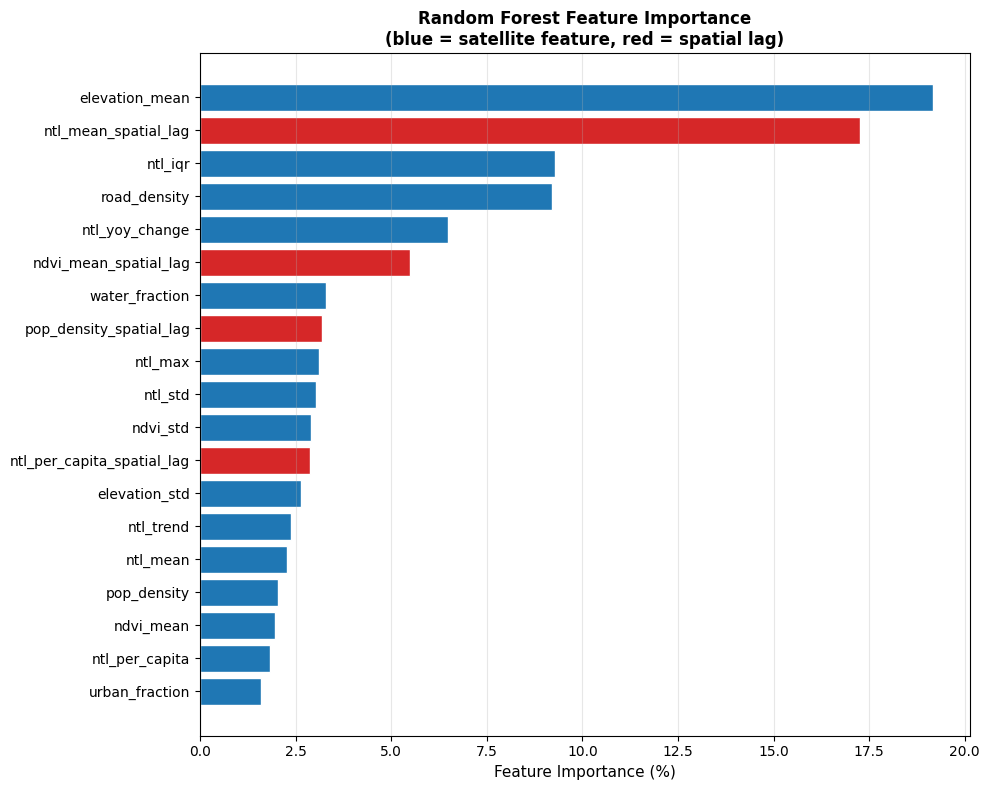


Saved: outputs/figures/feature_importance.png


In [10]:
# Fit on full dataset to get stable feature importances
scaler_fi = RobustScaler()
X_scaled_fi = scaler_fi.fit_transform(X)
best_rf.fit(X_scaled_fi, y)

importance_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df['importance_pct'] = (
    importance_df['importance'] * 100
).round(2)

print("Feature Importances (fitted on full dataset):")
print(importance_df[['feature', 'importance_pct']].to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if 'spatial' in f else '#1f77b4' 
          for f in importance_df['feature']]
ax.barh(importance_df['feature'], importance_df['importance_pct'],
        color=colors, edgecolor='white')
ax.set_xlabel('Feature Importance (%)', fontsize=11)
ax.set_title('Random Forest Feature Importance\n'
             '(blue = satellite feature, red = spatial lag)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/figures/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: outputs/figures/feature_importance.png")

In [11]:
import joblib
import geopandas as gpd

# Save the tuned model and scaler
scaler_final = RobustScaler()
X_scaled_final = scaler_final.fit_transform(X)

final_rf = RandomForestRegressor(
    max_depth=None, max_features=0.7,
    min_samples_leaf=1, n_estimators=100,
    random_state=42
)
final_rf.fit(X_scaled_final, y)

joblib.dump(final_rf,     "models/random_forest_final.pkl")
joblib.dump(scaler_final, "models/scaler_final.pkl")
joblib.dump(FEATURE_COLS, "models/feature_cols.pkl")
print("Saved: models/random_forest_final.pkl")
print("Saved: models/scaler_final.pkl")
print("Saved: models/feature_cols.pkl")

# Generate predictions for all 64 districts
df['poverty_predicted'] = final_rf.predict(X_scaled_final)

# Load geodata and attach predictions
gdf = gpd.read_file("data/processed/master_features.gpkg")
gdf['poverty_predicted'] = df['poverty_predicted'].values
gdf['prediction_error']  = (gdf['poverty_predicted'] - gdf['poverty_hcr']).round(3)

Saved: models/random_forest_final.pkl
Saved: models/scaler_final.pkl
Saved: models/feature_cols.pkl


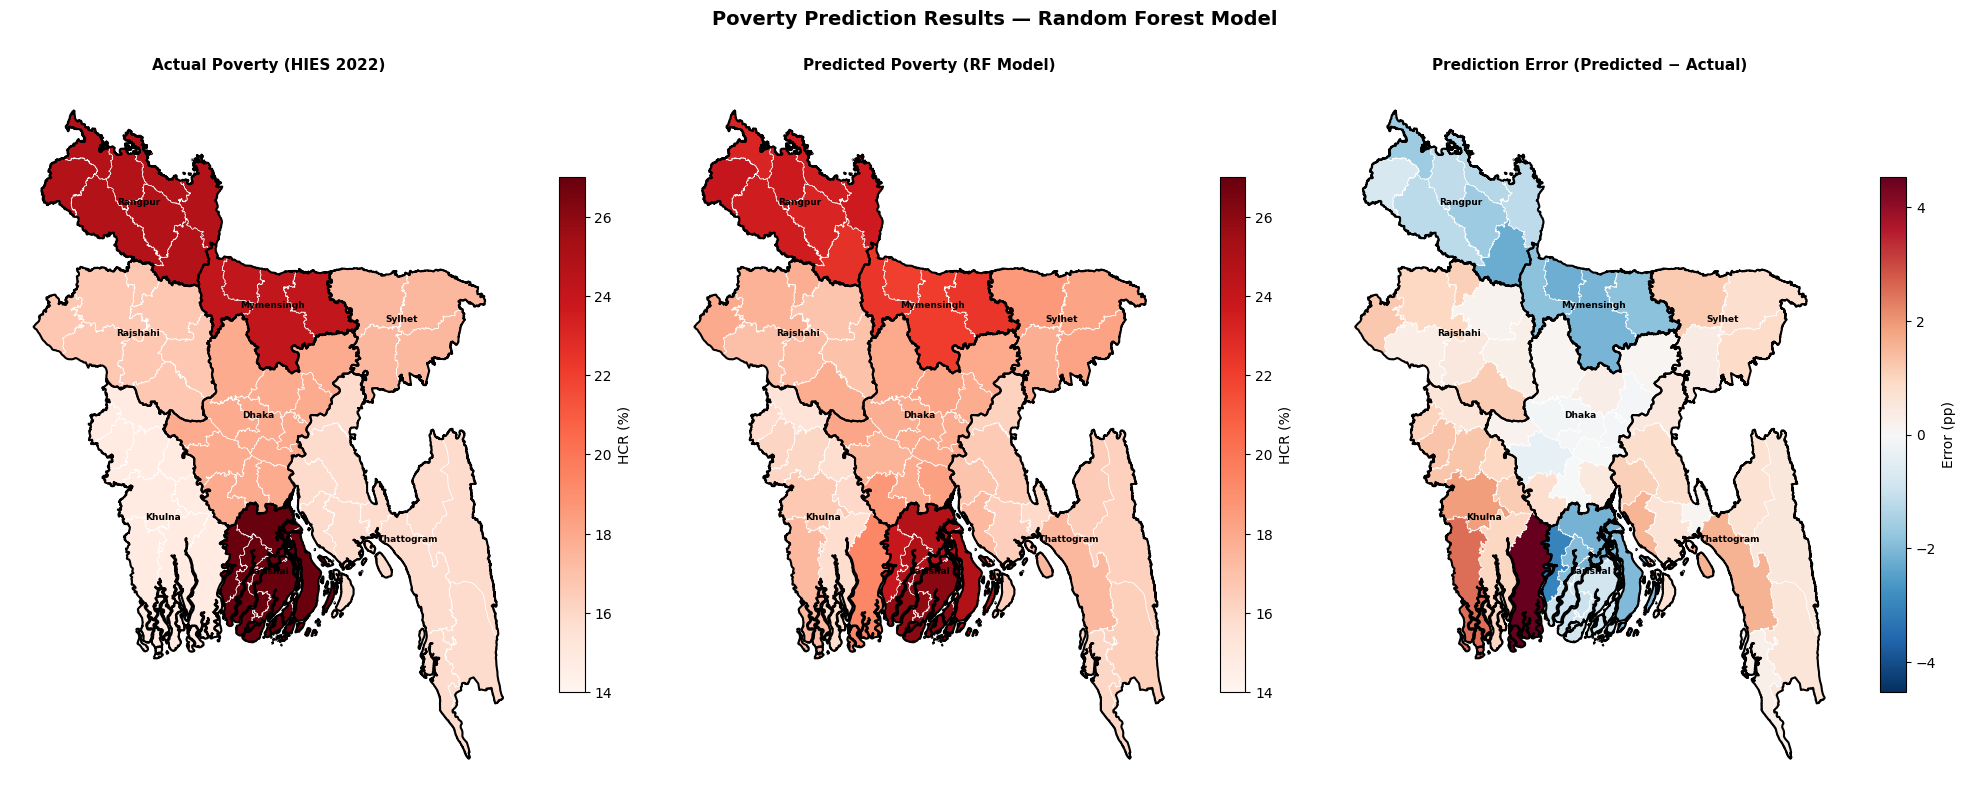

Saved: outputs/maps/poverty_prediction_map.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle('Poverty Prediction Results — Random Forest Model',
             fontsize=14, fontweight='bold', y=1.01)

division_boundaries = gdf.dissolve(by='division_name')

def add_division_labels(ax):
    for div, row in division_boundaries.iterrows():
        c = row.geometry.centroid
        ax.annotate(div, xy=(c.x, c.y), ha='center',
                    fontsize=6.5, fontweight='bold')

# Panel 1 — Actual poverty
gdf.plot(column='poverty_hcr', cmap='Reds', linewidth=0.5,
         edgecolor='white', legend=True, ax=axes[0],
         legend_kwds={'shrink': 0.7, 'label': 'HCR (%)'},
         vmin=14, vmax=27)
division_boundaries.boundary.plot(ax=axes[0], linewidth=1.5, edgecolor='black')
add_division_labels(axes[0])
axes[0].set_title('Actual Poverty (HIES 2022)', fontsize=11, fontweight='bold')
axes[0].axis('off')

# Panel 2 — Predicted poverty
gdf.plot(column='poverty_predicted', cmap='Reds', linewidth=0.5,
         edgecolor='white', legend=True, ax=axes[1],
         legend_kwds={'shrink': 0.7, 'label': 'HCR (%)'},
         vmin=14, vmax=27)
division_boundaries.boundary.plot(ax=axes[1], linewidth=1.5, edgecolor='black')
add_division_labels(axes[1])
axes[1].set_title('Predicted Poverty (RF Model)', fontsize=11, fontweight='bold')
axes[1].axis('off')

# Panel 3 — Prediction error
vmax_err = gdf['prediction_error'].abs().max()
gdf.plot(column='prediction_error', cmap='RdBu_r', linewidth=0.5,
         edgecolor='white', legend=True, ax=axes[2],
         legend_kwds={'shrink': 0.7, 'label': 'Error (pp)'},
         vmin=-vmax_err, vmax=vmax_err)
division_boundaries.boundary.plot(ax=axes[2], linewidth=1.5, edgecolor='black')
add_division_labels(axes[2])
axes[2].set_title('Prediction Error (Predicted − Actual)',
                  fontsize=11, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.savefig("outputs/maps/poverty_prediction_map.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/maps/poverty_prediction_map.png")

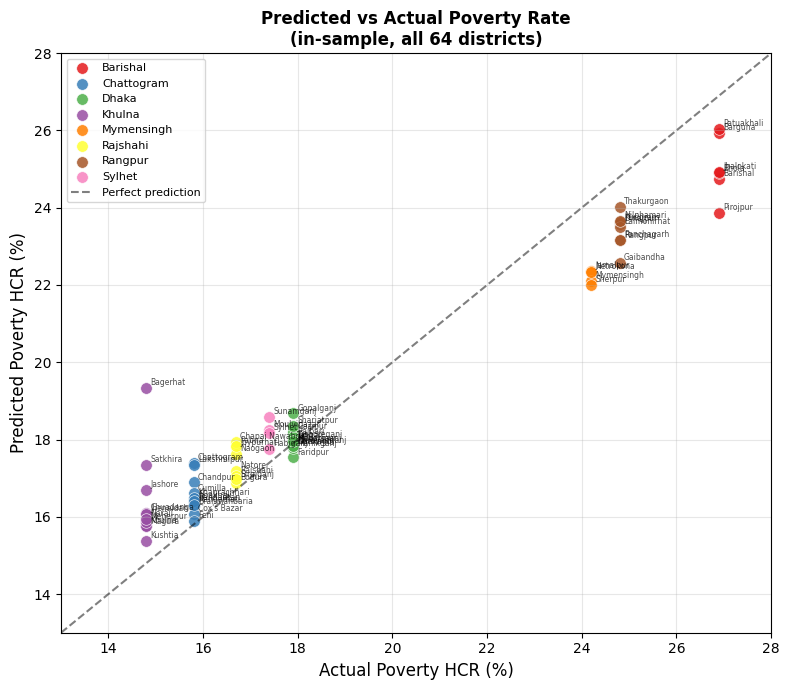


=== FINAL MODEL SUMMARY ===
Model:           Tuned Random Forest
Features:        19 satellite + spatial features
Samples:         64 districts
Validation:      Leave-One-District-Out CV

RMSE:            3.626 pp  (naive baseline: 4.163)
MAE:             2.926 pp  (naive baseline: 3.596)
R²:              0.241
vs Naive:        12.9% improvement in RMSE

Top 3 features:
  elevation_mean                 19.2%
  ntl_mean_spatial_lag           17.3%
  ntl_iqr                        9.3%


In [13]:
fig, ax = plt.subplots(figsize=(8, 7))

divisions_list = df['division_name'].unique()
colors = plt.cm.Set1.colors
div_color = {d: colors[i] for i, d in enumerate(sorted(divisions_list))}

for div in sorted(divisions_list):
    mask = df['division_name'] == div
    ax.scatter(df.loc[mask, 'poverty_hcr'],
               df.loc[mask, 'poverty_predicted'],
               color=div_color[div], label=div,
               s=70, alpha=0.85, edgecolors='white', linewidth=0.5)
    # Label each point with district name
    for _, row in df[mask].iterrows():
        ax.annotate(row['district_name'],
                    xy=(row['poverty_hcr'], row['poverty_predicted']),
                    fontsize=5.5, alpha=0.7,
                    xytext=(3, 2), textcoords='offset points')

# Perfect prediction line
lims = [13, 28]
ax.plot(lims, lims, 'k--', linewidth=1.5, alpha=0.5, label='Perfect prediction')

ax.set_xlabel('Actual Poverty HCR (%)', fontsize=12)
ax.set_ylabel('Predicted Poverty HCR (%)', fontsize=12)
ax.set_title('Predicted vs Actual Poverty Rate\n(in-sample, all 64 districts)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.tight_layout()
plt.savefig("outputs/figures/predicted_vs_actual.png",
            dpi=150, bbox_inches='tight')
plt.show()

# Final summary table
print("\n=== FINAL MODEL SUMMARY ===")
print(f"Model:           Tuned Random Forest")
print(f"Features:        {len(FEATURE_COLS)} satellite + spatial features")
print(f"Samples:         64 districts")
print(f"Validation:      Leave-One-District-Out CV")
print(f"")
print(f"RMSE:            3.626 pp  (naive baseline: 4.163)")
print(f"MAE:             2.926 pp  (naive baseline: 3.596)")
print(f"R²:              0.241")
print(f"vs Naive:        12.9% improvement in RMSE")
print(f"")
print(f"Top 3 features:")
for _, row in importance_df.head(3).iterrows():
    print(f"  {row['feature']:<30} {row['importance_pct']:.1f}%")